# Fertility and median income: exploratory data analysis

This notebook loads two Our World in Data datasets from `fertility/` and explores their structure. We keep only **countries** (3-letter ISO-style codes) and exclude regions, income groups, continents, and subnational entities.

Run from the repo root after activating the conda environment:

    conda activate ProbablyOverthinkingIt
    jupytext --to ipynb notebooks/fertility.md


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from pathlib import Path

DATA_DIR = Path("fertility")
FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

In [3]:
LOG_INCOME_TICK_CANDIDATES = [1, 2, 4, 8, 16, 32, 64]


def log_income_ticks(ymin: float, ymax: float) -> list[int]:
    return [t for t in LOG_INCOME_TICK_CANDIDATES if ymin <= t <= ymax]


def set_log_income_yticks(ax) -> None:
    ymin, ymax = ax.get_ylim()
    ticks = log_income_ticks(ymin, ymax)
    if ticks:
        ax.set_yticks(ticks)
        ax.set_yticklabels([str(t) for t in ticks])

## Load data

In [4]:
fertility = pd.read_csv(DATA_DIR / "children-born-per-woman.csv")
income = pd.read_csv(DATA_DIR / "daily-median-income.csv")

fertility.head()

,Entity,Code,Year,Total fertility rate
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


In [5]:
income.head()

,Entity,Code,Year,Median
0,Albania,ALB,1996,7.419330
1,Albania,ALB,2002,7.117154
2,Albania,ALB,2005,8.300111
3,Albania,ALB,2008,8.939033
4,Albania,ALB,2012,8.768967


## Select countries only

OWID entity codes distinguish countries from regions:

- **Countries:** 3-letter alphabetic codes (e.g. `USA`, `IND`) — usually ISO alpha-3
- **Regions / aggregates:** `OWID_*`, `UN_*`, `WB_*` prefixes, or blank codes for subnational splits

In [6]:
def is_country(code) -> bool:
    """True for standard 3-letter country codes."""
    return isinstance(code, str) and len(code) == 3 and code.isalpha()


def keep_countries(df: pd.DataFrame) -> pd.DataFrame:
    mask = df["Code"].apply(is_country)
    return df.loc[mask].copy()


fertility_cty = keep_countries(fertility)
income_cty = keep_countries(income)

print(f"Fertility: {fertility_cty['Entity'].nunique()} countries, {len(fertility_cty):,} rows")
print(f"  (from {fertility['Entity'].nunique()} entities, {len(fertility):,} rows)")
print(f"Income:    {income_cty['Entity'].nunique()} countries, {len(income_cty):,} rows")
print(f"  (from {income['Entity'].nunique()} entities, {len(income):,} rows)")

Fertility: 236 countries, 17,683 rows
  (from 261 entities, 19,402 rows)
Income:    170 countries, 2,274 rows
  (from 193 entities, 2,759 rows)


Excluded entities (regions, aggregates, subnational):

In [7]:
def excluded_entities(df: pd.DataFrame) -> pd.DataFrame:
    mask = ~df["Code"].apply(is_country)
    return (
        df.loc[mask, ["Entity", "Code"]]
        .drop_duplicates()
        .sort_values("Entity")
        .reset_index(drop=True)
    )


display(excluded_entities(fertility).head(15))
display(excluded_entities(income).head(15))

,Entity,Code
0,Africa,OWID_AFR
1,Africa (UN),UN_AFR
2,Asia,OWID_ASI
3,Asia (UN),UN_ASI
4,England and Wales,NaN
5,Europe,OWID_EUR
6,Europe (UN),UN_EUR
7,High-income countries,OWID_HIC
8,Kosovo,OWID_KOS
9,Latin America and the Caribbean (UN),UN_LAC


,Entity,Code
0,Argentina (urban),NaN
1,Bolivia (urban),NaN
2,China (rural),NaN
3,China (urban),NaN
4,Colombia (urban),NaN
5,East Asia and Pacific (WB),WB_EAP
6,Eastern and Southern Africa (WB),NaN
7,Ecuador (urban),NaN
8,Ethiopia (rural),NaN
9,Europe and Central Asia (WB),WB_ECA


## Fertility rate EDA

In [8]:
fertility_cty = fertility_cty.rename(
    columns={"Total fertility rate": "fertility_rate"}
)
fertility_cty["Year"] = fertility_cty["Year"].astype(int)

fertility_cty.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17683 entries, 0 to 19401
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Entity          17683 non-null  object 
 1   Code            17683 non-null  object 
 2   Year            17683 non-null  int64  
 3   fertility_rate  17683 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 690.7+ KB


In [9]:
fertility_cty.describe()

,Year,fertility_rate
count,17683.000000,17683.000000
mean,1985.839903,3.958980
std,22.086600,2.017906
min,1891.000000,0.662000
25%,1967.000000,2.123500
50%,1986.000000,3.491000
75%,2005.000000,5.913500
max,2023.000000,8.864000


In [10]:
obs_per_country = (
    fertility_cty.groupby("Entity")
    .agg(
        code=("Code", "first"),
        n_obs=("Year", "count"),
        year_min=("Year", "min"),
        year_max=("Year", "max"),
        fertility_min=("fertility_rate", "min"),
        fertility_max=("fertility_rate", "max"),
    )
    .sort_values("n_obs", ascending=False)
)

obs_per_country.head(10)

,code,n_obs,year_min,year_max,fertility_min,fertility_max
Entity,,,,,,
Sweden,SWE,133,1891,2023,1.430,4.142
Denmark,DNK,108,1916,2023,1.378,3.264
Canada,CAN,103,1921,2023,1.349,3.855
Spain,ESP,102,1922,2023,1.131,4.098
Switzerland,CHE,92,1932,2023,1.382,2.653
United States,USA,91,1933,2023,1.616,3.754
Finland,FIN,85,1939,2023,1.280,3.463
Portugal,PRT,84,1940,2023,1.213,3.482
France,FRA,78,1946,2023,1.639,3.038


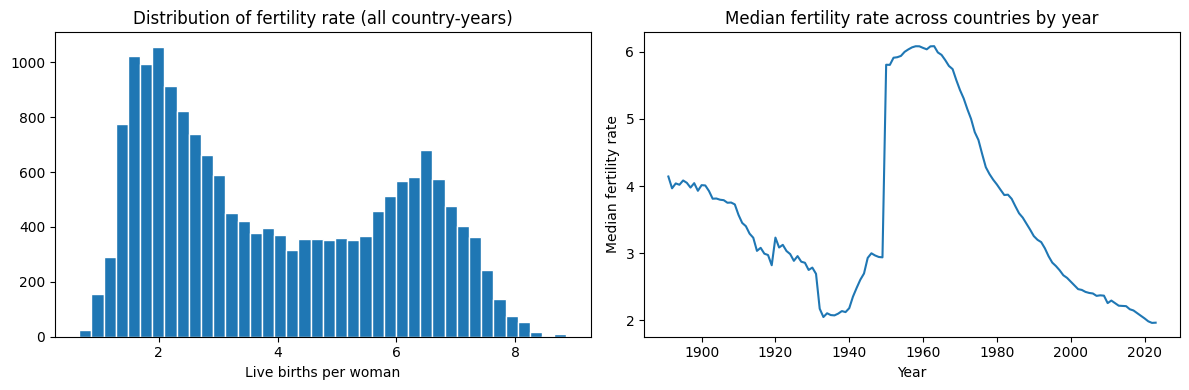

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fertility_cty["fertility_rate"], bins=40, edgecolor="white")
axes[0].set_title("Distribution of fertility rate (all country-years)")
axes[0].set_xlabel("Live births per woman")

fertility_cty.groupby("Year")["fertility_rate"].median().plot(ax=axes[1])
axes[1].set_title("Median fertility rate across countries by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median fertility rate")

plt.tight_layout()
plt.show()

Time series for a few large countries:

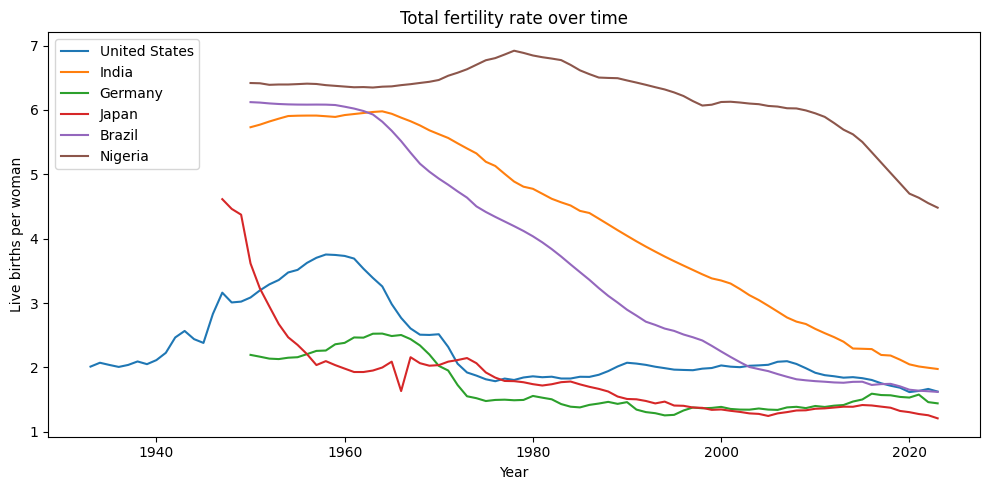

In [12]:
highlight = ["United States", "India", "Germany", "Japan", "Brazil", "Nigeria"]

fig, ax = plt.subplots(figsize=(10, 5))
for country in highlight:
    subset = fertility_cty.loc[fertility_cty["Entity"] == country]
    if subset.empty:
        continue
    ax.plot(subset["Year"], subset["fertility_rate"], label=country)

ax.set_title("Total fertility rate over time")
ax.set_xlabel("Year")
ax.set_ylabel("Live births per woman")
ax.legend()
plt.tight_layout()
plt.show()

## Median daily income EDA

In [13]:
income_cty = income_cty.rename(columns={"Median": "median_income"})
income_cty["Year"] = income_cty["Year"].astype(int)

income_cty.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2274 entries, 0 to 2758
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Entity         2274 non-null   object 
 1   Code           2274 non-null   object 
 2   Year           2274 non-null   int64  
 3   median_income  2274 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 88.8+ KB


In [14]:
income_cty.describe()

,Year,median_income
count,2274.000000,2274.000000
mean,2007.396658,23.251871
std,11.298693,20.411582
min,1963.000000,0.796325
25%,2001.000000,6.718461
50%,2009.000000,14.120466
75%,2016.000000,39.436756
max,2025.000000,89.485191


In [15]:
income_obs = (
    income_cty.groupby("Entity")
    .agg(
        code=("Code", "first"),
        n_obs=("Year", "count"),
        year_min=("Year", "min"),
        year_max=("Year", "max"),
        median_min=("median_income", "min"),
        median_max=("median_income", "max"),
    )
    .sort_values("n_obs", ascending=False)
)

income_obs.head(10)

,code,n_obs,year_min,year_max,median_min,median_max
Entity,,,,,,
United States,USA,62,1963,2024,33.291943,74.139931
United Kingdom,GBR,54,1968,2021,20.924421,54.921055
Canada,CAN,46,1971,2022,29.218575,67.081757
Brazil,BRA,40,1981,2024,4.125918,16.912106
Costa Rica,CRI,39,1981,2025,4.570024,23.389744
Luxembourg,LUX,39,1985,2023,43.311543,89.485191
Italy,ITA,38,1977,2023,23.130226,49.936432
Indonesia,IDN,33,1984,2025,1.608644,6.655952
France,FRA,33,1970,2023,22.592022,57.468567


Survey years are sparse and irregular compared to the annual fertility series:

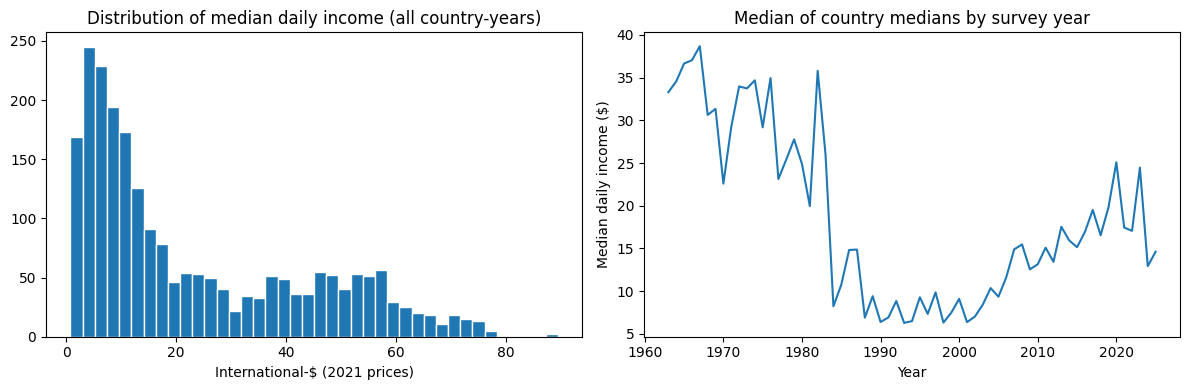

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(income_cty["median_income"], bins=40, edgecolor="white")
axes[0].set_title("Distribution of median daily income (all country-years)")
axes[0].set_xlabel("International-$ (2021 prices)")

income_cty.groupby("Year")["median_income"].median().plot(ax=axes[1])
axes[1].set_title("Median of country medians by survey year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median daily income ($)")

plt.tight_layout()
plt.show()

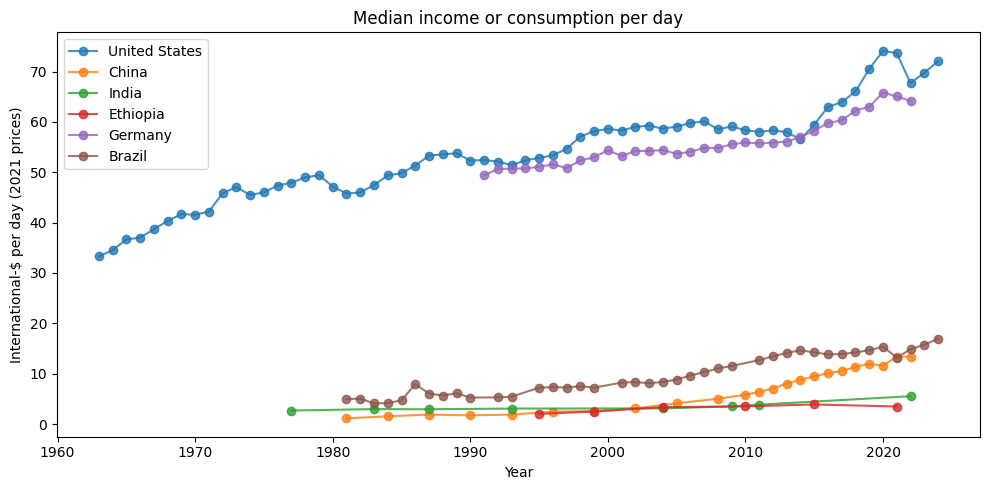

In [17]:
income_highlight = [
    "United States",
    "China",
    "India",
    "Ethiopia",
    "Germany",
    "Brazil",
]

fig, ax = plt.subplots(figsize=(10, 5))
for country in income_highlight:
    subset = income_cty.loc[income_cty["Entity"] == country]
    if subset.empty:
        continue
    ax.plot(subset["Year"], subset["median_income"], "o-", label=country, alpha=0.8)

ax.set_title("Median income or consumption per day")
ax.set_xlabel("Year")
ax.set_ylabel("International-$ per day (2021 prices)")
ax.legend()
plt.tight_layout()
plt.show()

## Overlap between datasets

In [18]:
fertility_countries = set(fertility_cty["Entity"])
income_countries = set(income_cty["Entity"])

both = fertility_countries & income_countries
only_fertility = fertility_countries - income_countries
only_income = income_countries - fertility_countries

print(f"Countries in both datasets: {len(both)}")
print(f"Only in fertility:        {len(only_fertility)}")
print(f"Only in income:           {len(only_income)}")

Countries in both datasets: 170
Only in fertility:        66
Only in income:           0


In [19]:
overlap = fertility_cty.merge(
    income_cty,
    on=["Entity", "Code", "Year"],
    how="inner",
    suffixes=("_fertility", "_income"),
)

print(f"Country-year rows in both datasets: {len(overlap):,}")
overlap.head()

Country-year rows in both datasets: 2,246


,Entity,Code,Year,fertility_rate,median_income
0,Albania,ALB,1996,2.666,7.419330
1,Albania,ALB,2002,2.002,7.117154
2,Albania,ALB,2005,1.787,8.300111
3,Albania,ALB,2008,1.616,8.939033
4,Albania,ALB,2012,1.719,8.768967


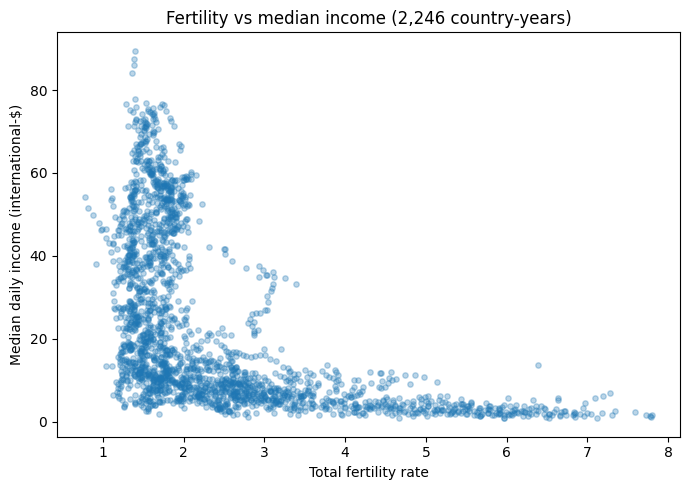

In [20]:
if len(overlap) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        overlap["fertility_rate"],
        overlap["median_income"],
        alpha=0.3,
        s=15,
    )
    ax.set_xlabel("Total fertility rate")
    ax.set_ylabel("Median daily income (international-$)")
    ax.set_title(f"Fertility vs median income ({len(overlap):,} country-years)")
    plt.tight_layout()
    plt.show()

## Income trajectories with fertility markers

Countries present in both datasets, from 1960 onward. Each country gets a faint income trajectory on a log-scaled y-axis; markers at survey years are shaped by fertility threshold and colored blue (low fertility), red (high fertility), or purple (near replacement).

In [21]:
MIN_YEAR = 1960
FERTILITY_LOW = 2.0
FERTILITY_HIGH = 2.2

both_countries = fertility_countries & income_countries

fertility_both = fertility_cty.loc[
    fertility_cty["Entity"].isin(both_countries) & (fertility_cty["Year"] >= MIN_YEAR)
]
income_both = income_cty.loc[
    income_cty["Entity"].isin(both_countries) & (income_cty["Year"] >= MIN_YEAR)
]

merged_both = fertility_both.merge(
    income_both,
    on=["Entity", "Code", "Year"],
    how="inner",
)

print(f"Countries in both datasets: {len(both_countries)}")
print(f"Income observations (1960+): {len(income_both):,}")
print(f"Country-years with both measures: {len(merged_both):,}")
merged_both.head()

Countries in both datasets: 170
Income observations (1960+): 2,274
Country-years with both measures: 2,246


,Entity,Code,Year,fertility_rate,median_income
0,Albania,ALB,1996,2.666,7.419330
1,Albania,ALB,2002,2.002,7.117154
2,Albania,ALB,2005,1.787,8.300111
3,Albania,ALB,2008,1.616,8.939033
4,Albania,ALB,2012,1.719,8.768967


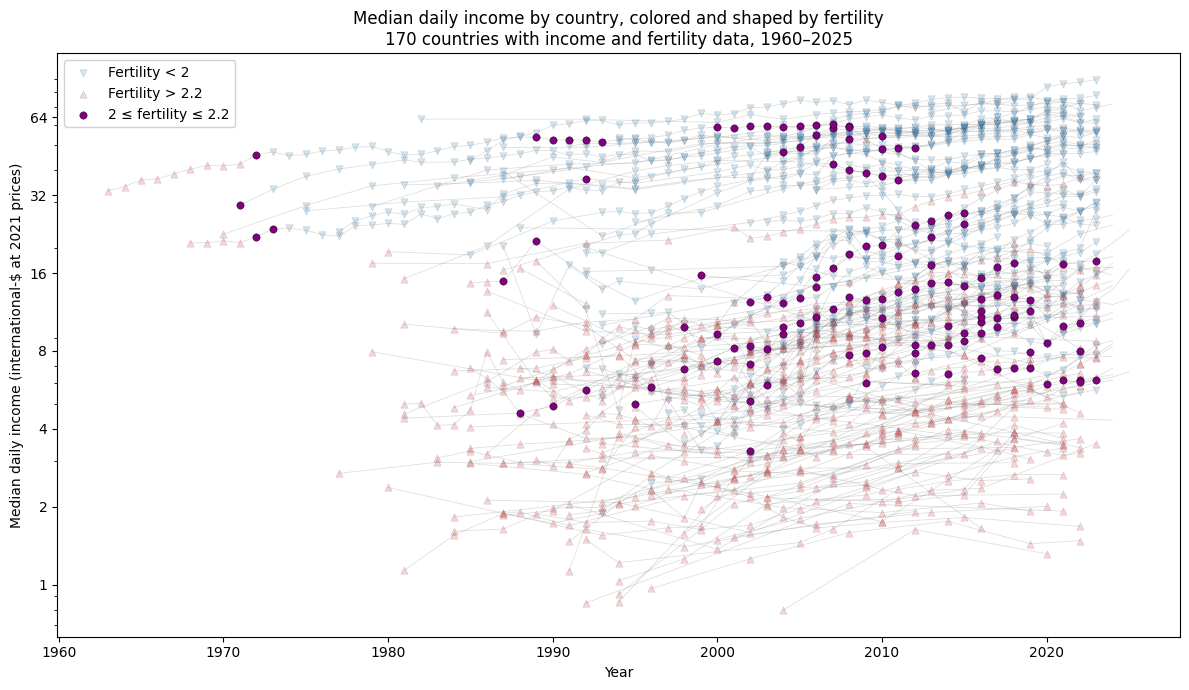

In [22]:
def fertility_marker(rate: float) -> str:
    if rate < FERTILITY_LOW:
        return "v"
    if rate > FERTILITY_HIGH:
        return "^"
    return "o"


fig, ax = plt.subplots(figsize=(12, 7))

for country, group in income_both.groupby("Entity"):
    group = group.sort_values("Year")
    ax.plot(
        group["Year"],
        group["median_income"],
        color="0.5",
        linewidth=0.6,
        alpha=0.25,
        zorder=1,
    )

marker_specs = {
    "v": {"label": "Fertility < 2", "color": "tab:blue", "alpha": 0.2},
    "^": {"label": "Fertility > 2.2", "color": "tab:red", "alpha": 0.2},
    "o": {"label": "2 ≤ fertility ≤ 2.2", "color": "purple", "alpha": 1.0},
}

for marker, spec in marker_specs.items():
    subset = merged_both.loc[merged_both["fertility_rate"].map(fertility_marker) == marker]
    ax.scatter(
        subset["Year"],
        subset["median_income"],
        marker=marker,
        c=spec["color"],
        s=28,
        edgecolors="0.0",
        linewidths=0.3,
        alpha=spec["alpha"],
        label=spec["label"],
        zorder=2,
    )

ax.set_yscale("log")
set_log_income_yticks(ax)
ax.set_title(
    "Median daily income by country, colored and shaped by fertility\n"
    f"{len(both_countries)} countries with income and fertility data, {MIN_YEAR}–{income_both['Year'].max()}"
)
ax.set_xlabel("Year")
ax.set_ylabel("Median daily income (international-$ at 2021 prices)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

## First year below replacement fertility

For each country, find the first year when fertility dropped below 2.1, considering only data from 1950 onward. This ignores temporary dips during the Depression and WWII that later rebounded above replacement. Income in the crossing year is estimated from survey data; when there is no survey in that year, interpolate log(income) linearly between surrounding survey years (or extrapolate flat in log-space beyond the survey range).

In [23]:
FERTILITY_CROSSING = 2.1
CROSSING_MIN_YEAR = 1950

fertility_crossing = fertility_cty.loc[
    fertility_cty["Entity"].isin(both_countries)
    & (fertility_cty["Year"] >= CROSSING_MIN_YEAR)
]
income_crossing = income_cty.loc[income_cty["Entity"].isin(both_countries)]

first_below = (
    fertility_crossing.loc[fertility_crossing["fertility_rate"] < FERTILITY_CROSSING]
    .sort_values("Year")
    .groupby("Entity", as_index=False)
    .first()
    .rename(columns={"Year": "crossing_year"})
)


def income_at_crossing(entity: str, crossing_year: int) -> pd.Series | None:
    country_income = income_crossing.loc[income_crossing["Entity"] == entity].sort_values("Year")
    if country_income.empty:
        return None

    years = country_income["Year"].to_numpy()
    log_income = np.log(country_income["median_income"].to_numpy())

    exact = country_income.loc[country_income["Year"] == crossing_year]
    if not exact.empty:
        return pd.Series(
            {
                "median_income": exact.iloc[0]["median_income"],
                "income_method": "exact",
            }
        )

    interpolated_log = np.interp(crossing_year, years, log_income)
    if crossing_year < years.min() or crossing_year > years.max():
        method = "extrapolated"
    else:
        method = "interpolated"

    return pd.Series(
        {
            "median_income": np.exp(interpolated_log),
            "income_method": method,
        }
    )


crossing_rows = []
for _, row in first_below.iterrows():
    income_row = income_at_crossing(row["Entity"], row["crossing_year"])
    if income_row is None:
        continue
    crossing_rows.append(
        {
            "Entity": row["Entity"],
            "Code": row["Code"],
            "crossing_year": row["crossing_year"],
            "fertility_rate": row["fertility_rate"],
            "median_income": income_row["median_income"],
            "income_method": income_row["income_method"],
        }
    )

crossing = pd.DataFrame(crossing_rows)

print(f"Countries that dropped below {FERTILITY_CROSSING} (since {CROSSING_MIN_YEAR}): {len(first_below)}")
print(f"With income estimate: {len(crossing)}")
print(crossing["income_method"].value_counts().to_string())
crossing.sort_values("crossing_year").head(10)

Countries that dropped below 2.1 (since 1950): 85
With income estimate: 85
income_method
extrapolated    49
interpolated    19
exact           17


,Entity,Code,crossing_year,fertility_rate,median_income,income_method
43,Luxembourg,LUX,1950,1.960,43.311543,extrapolated
3,Austria,AUT,1950,2.089,53.019806,extrapolated
41,Latvia,LVA,1950,2.075,8.500325,extrapolated
25,Estonia,EST,1956,1.973,10.067221,extrapolated
39,Japan,JPN,1957,2.036,41.739258,extrapolated
32,Hungary,HUN,1959,2.079,20.369560,extrapolated
21,Czechia,CZE,1959,2.096,19.164007,extrapolated
61,Romania,ROU,1962,2.023,17.787334,extrapolated
64,Serbia,SRB,1963,2.084,12.627927,extrapolated
78,Ukraine,UKR,1964,2.014,6.888254,extrapolated


Trend in log(income) versus crossing year, with and without China:

In [24]:
def crossing_trend_slope(df: pd.DataFrame) -> tuple[float, float]:
    x = df["crossing_year"].to_numpy()
    log_income = np.log(df["median_income"].to_numpy())
    return np.polyfit(x, log_income, 1)


crossing_no_china = crossing.loc[crossing["Entity"] != "China"]

slope_with_china, intercept_with_china = crossing_trend_slope(crossing)
slope_without_china, intercept_without_china = crossing_trend_slope(crossing_no_china)

china = crossing.loc[crossing["Entity"] == "China"].iloc[0]

trend_comparison = pd.DataFrame(
    {
        "sample": ["All crossed countries", "Excluding China"],
        "n_countries": [len(crossing), len(crossing_no_china)],
        "log_income_slope": [slope_with_china, slope_without_china],
        "income_ratio_per_year": [np.exp(slope_with_china), np.exp(slope_without_china)],
    }
)
trend_comparison

print(f"China crossed in {china['crossing_year']:.0f} at income {china['median_income']:.2f}")
print(f"Slope with China:    {slope_with_china:.5f} log-$ per year")
print(f"Slope without China: {slope_without_china:.5f} log-$ per year")

China crossed in 1991 at income 1.78
Slope with China:    -0.01829 log-$ per year
Slope without China: -0.01810 log-$ per year


Countries that have **not** crossed below 2.1 — potential survivorship-bias outliers. We identify them using fertility in 2023 (the last available year) and plot them at **2024**, the earliest year they could have crossed. Income is estimated for 2024 the same way as for crossing years.

In [25]:
FERTILITY_YEAR = 2023
NOT_CROSSED_YEAR = 2024
INCOME_THRESHOLD = 8

print(f"Last year of fertility data: {fertility_cty['Year'].max()}")
assert fertility_cty["Year"].max() == FERTILITY_YEAR

crossed_entities = set(first_below["Entity"])

fertility_2023 = fertility_cty.loc[
    (fertility_cty["Year"] == FERTILITY_YEAR)
    & fertility_cty["Entity"].isin(both_countries)
    & ~fertility_cty["Entity"].isin(crossed_entities)
    & (fertility_cty["fertility_rate"] > FERTILITY_CROSSING)
]

not_crossed_rows = []
for _, row in fertility_2023.iterrows():
    income_row = income_at_crossing(row["Entity"], NOT_CROSSED_YEAR)
    if income_row is None:
        continue
    not_crossed_rows.append(
        {
            "Entity": row["Entity"],
            "Code": row["Code"],
            "crossing_year": NOT_CROSSED_YEAR,
            "fertility_rate": row["fertility_rate"],
            "median_income": income_row["median_income"],
            "income_method": income_row["income_method"],
            "point_type": "not_crossed",
        }
    )

not_crossed_all = pd.DataFrame(not_crossed_rows)
not_crossed_above = not_crossed_all.loc[
    not_crossed_all["median_income"] > INCOME_THRESHOLD
].copy()
not_crossed_below = not_crossed_all.loc[
    not_crossed_all["median_income"] <= INCOME_THRESHOLD
].copy()

survivors = not_crossed_above
crossing = crossing.assign(point_type="crossed")

print(
    f"Countries still above {FERTILITY_CROSSING} in {FERTILITY_YEAR} "
    f"with income data at {NOT_CROSSED_YEAR}: {len(not_crossed_all)}"
)
print(f"  income > ${INCOME_THRESHOLD}: {len(not_crossed_above)}")
print(f"  income <= ${INCOME_THRESHOLD}: {len(not_crossed_below)}")
not_crossed_above.sort_values("median_income", ascending=False)

Last year of fertility data: 2023
Countries still above 2.1 in 2023 with income data at 2024: 85
  income > $8: 21
  income <= $8: 64


,Entity,Code,crossing_year,fertility_rate,median_income,income_method,point_type
34,Israel,ISR,2024,2.830,37.484653,extrapolated,not_crossed
59,Panama,PAN,2024,2.119,18.576395,exact,not_crossed
16,Dominican Republic,DOM,2024,2.243,17.477671,exact,not_crossed
4,Bolivia,BOL,2024,2.547,16.819115,exact,not_crossed
61,Paraguay,PRY,2024,2.422,14.921974,exact,not_crossed
71,Suriname,SUR,2024,2.249,14.437642,extrapolated,not_crossed
80,Uzbekistan,UZB,2024,3.500,13.775327,exact,not_crossed
35,Jordan,JOR,2024,2.639,13.711074,extrapolated,not_crossed
58,Palestine,PSE,2024,3.311,12.048259,extrapolated,not_crossed
23,Gabon,GAB,2024,3.647,11.307635,extrapolated,not_crossed


Table of countries still above replacement in 2023 with income above \$8, sorted by 2023 income:

In [26]:
from IPython.display import HTML

late_crosser_rows = []
for _, row in survivors.iterrows():
    income_2023 = income_at_crossing(row["Entity"], FERTILITY_YEAR)
    late_crosser_rows.append(
        {
            "Country": row["Entity"],
            "Code": row["Code"],
            "fertility_2023": row["fertility_rate"],
            "income_2023": income_2023["median_income"],
            "income_method_2023": income_2023["income_method"],
        }
    )

late_crossers = (
    pd.DataFrame(late_crosser_rows)
    .sort_values("income_2023", ascending=False)
    .reset_index(drop=True)
)

table_rows = []
for _, row in late_crossers.iterrows():
    table_rows.append(
        "<tr>"
        f"<td>{row['Country']}</td>"
        f"<td>{row['fertility_2023']:.2f}</td>"
        f"<td>{row['income_2023']:.2f}</td>"
        f"<td>{row['income_method_2023']}</td>"
        "</tr>"
    )

late_crossers_html = (
    '<table class="late-crossers">\n'
    "<thead><tr>"
    "<th>Country</th><th>Fertility (2023)</th>"
    "<th>Income (2023, intl-$)</th><th>Income method</th>"
    "</tr></thead>\n<tbody>\n"
    + "\n".join(table_rows)
    + "\n</tbody></table>"
)

late_crossers_path = FIG_DIR / "late_crossers_table.html"
late_crossers_path.write_text(late_crossers_html, encoding="utf-8")
print(f"Wrote {late_crossers_path}")
HTML(late_crossers_html)

Wrote figs/late_crossers_table.html


Country,Fertility (2023),"Income (2023, intl-$)",Income method
Israel,2.83,37.48,extrapolated
Panama,2.12,17.90,exact
Bolivia,2.55,16.85,exact
Dominican Republic,2.24,15.67,exact
Suriname,2.25,14.44,extrapolated
Paraguay,2.42,14.33,exact
Jordan,2.64,13.71,extrapolated
Uzbekistan,3.50,12.55,exact
Palestine,3.31,12.05,exact
Gabon,3.65,11.31,extrapolated


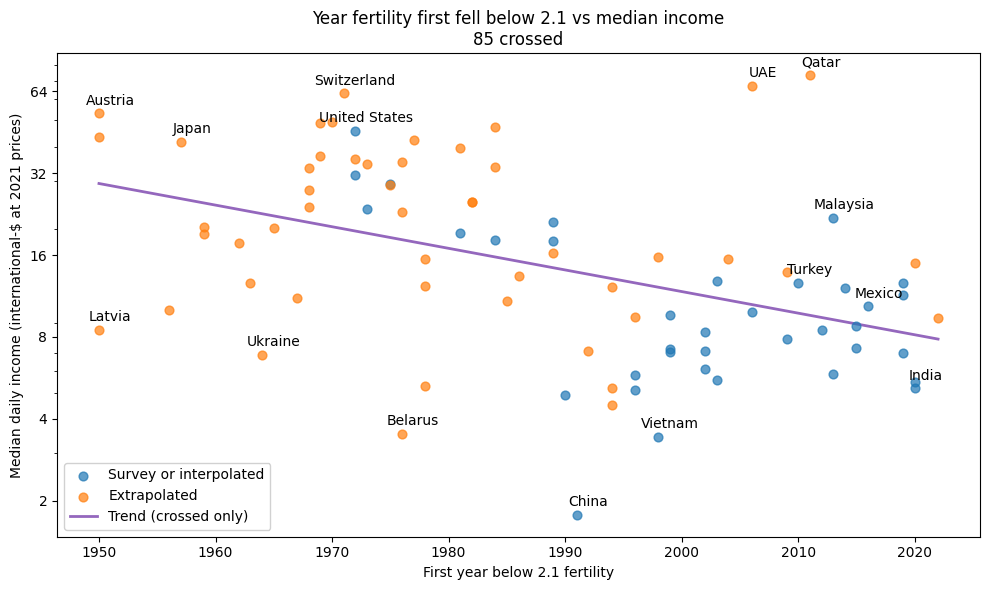

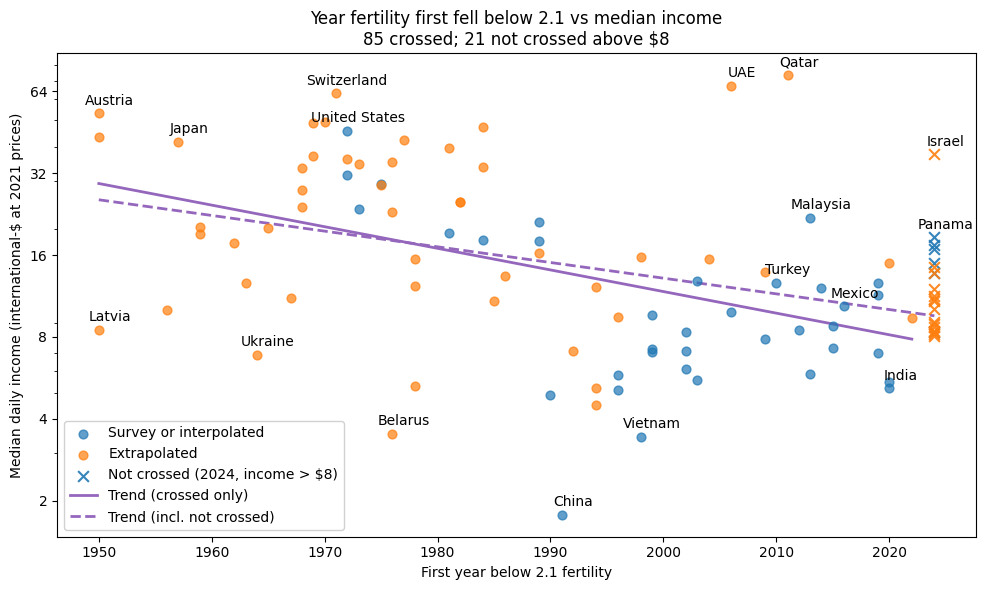

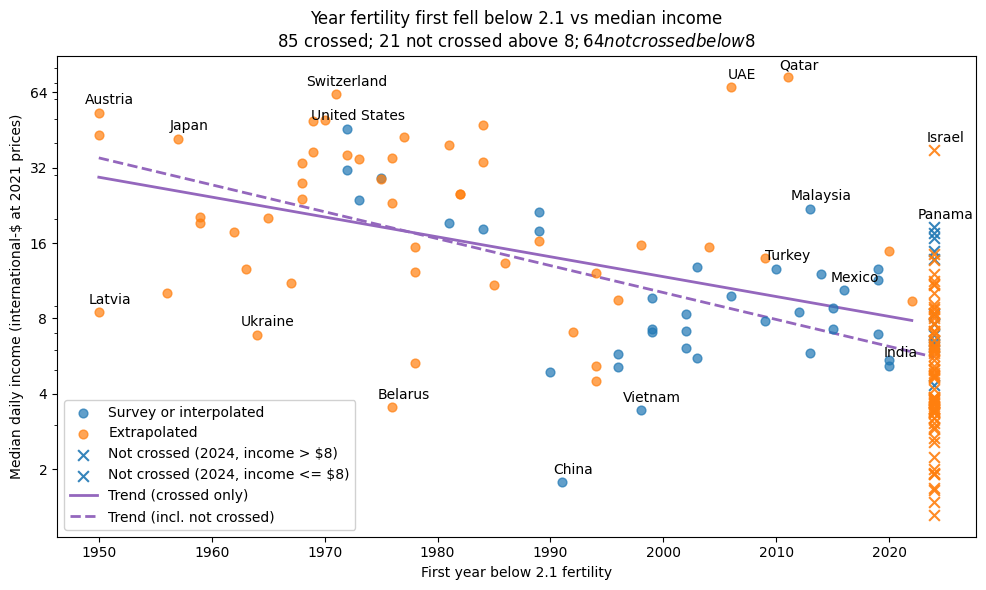

PosixPath('figs/fertility_crossing_scatter.png')

In [27]:
label_countries = ["India", "United States", "Malaysia", "Mexico", "Turkey",
                    "Qatar", "United Arab Emirates", "China", "Vietnam", "Belarus",
                    "Ukraine", "Japan", "Switzerland", "Latvia", "Austria", "Israel", "Panama"]
label_names = {"United Arab Emirates": "UAE"}


def not_crossed_subset(plot_above: bool, plot_below: bool) -> pd.DataFrame:
    parts = []
    if plot_above:
        parts.append(not_crossed_above)
    if plot_below:
        parts.append(not_crossed_below)
    if not parts:
        return pd.DataFrame(columns=not_crossed_all.columns)
    return pd.concat(parts, ignore_index=True)


def plot_not_crossed_markers(ax, group: pd.DataFrame, label: str) -> None:
    if group.empty:
        return

    survey_or_interp = group.loc[group["income_method"] != "extrapolated"]
    extrapolated = group.loc[group["income_method"] == "extrapolated"]

    if not survey_or_interp.empty:
        ax.scatter(
            survey_or_interp["crossing_year"],
            survey_or_interp["median_income"],
            marker="x",
            c="C0",
            s=60,
            linewidths=1.5,
            alpha=0.9,
            zorder=3,
            label=label,
        )
    if not extrapolated.empty:
        ax.scatter(
            extrapolated["crossing_year"],
            extrapolated["median_income"],
            marker="x",
            c="C1",
            s=60,
            linewidths=1.5,
            alpha=0.9,
            zorder=3,
        )


def crossing_subtitle(plot_above: bool, plot_below: bool) -> str:
    parts = [f"{len(crossing)} crossed"]
    if plot_above:
        parts.append(
            f"{len(not_crossed_above)} not crossed above ${INCOME_THRESHOLD:g}"
        )
    if plot_below:
        parts.append(
            f"{len(not_crossed_below)} not crossed below ${INCOME_THRESHOLD:g}"
        )
    return "; ".join(parts)


def plot_crossing_scatter(
    *,
    plot_above: bool,
    plot_below: bool,
    filename: str,
) -> tuple[float, float, float, float]:
    not_crossed_to_plot = not_crossed_subset(plot_above, plot_below)

    fig, ax = plt.subplots(figsize=(10, 6))

    survey_or_interp = crossing.loc[crossing["income_method"] != "extrapolated"]
    extrapolated = crossing.loc[crossing["income_method"] == "extrapolated"]

    ax.scatter(
        survey_or_interp["crossing_year"],
        survey_or_interp["median_income"],
        c="C0",
        s=40,
        alpha=0.7,
        zorder=2,
        label="Survey or interpolated",
    )
    ax.scatter(
        extrapolated["crossing_year"],
        extrapolated["median_income"],
        c="C1",
        s=40,
        alpha=0.7,
        zorder=2,
        label="Extrapolated",
    )

    if plot_above:
        plot_not_crossed_markers(
            ax,
            not_crossed_above,
            f"Not crossed ({NOT_CROSSED_YEAR}, income > ${INCOME_THRESHOLD:g})",
        )
    if plot_below:
        plot_not_crossed_markers(
            ax,
            not_crossed_below,
            f"Not crossed ({NOT_CROSSED_YEAR}, income <= ${INCOME_THRESHOLD:g})",
        )

    x = crossing["crossing_year"].to_numpy()
    log_income = np.log(crossing["median_income"].to_numpy())
    slope, intercept = np.polyfit(x, log_income, 1)

    x_trend = np.linspace(
        crossing["crossing_year"].min(),
        crossing["crossing_year"].max(),
        100,
    )
    y_trend = np.exp(slope * x_trend + intercept)
    ax.plot(
        x_trend,
        y_trend,
        color="C4",
        linewidth=2,
        zorder=1,
        label="Trend (crossed only)",
    )

    slope_all = intercept_all = None
    if not not_crossed_to_plot.empty:
        combined = pd.concat(
            [
                crossing[["crossing_year", "median_income"]],
                not_crossed_to_plot[["crossing_year", "median_income"]],
            ],
            ignore_index=True,
        )
        slope_all, intercept_all = np.polyfit(
            combined["crossing_year"],
            np.log(combined["median_income"]),
            1,
        )
        x_trend_all = np.linspace(
            combined["crossing_year"].min(),
            combined["crossing_year"].max(),
            100,
        )
        y_trend_all = np.exp(slope_all * x_trend_all + intercept_all)
        ax.plot(
            x_trend_all,
            y_trend_all,
            color="C4",
            linewidth=2,
            linestyle="--",
            zorder=1,
            label="Trend (incl. not crossed)",
        )

    for country in label_countries:
        row = crossing.loc[crossing["Entity"] == country]
        if row.empty:
            row = not_crossed_to_plot.loc[not_crossed_to_plot["Entity"] == country]
        if row.empty:
            continue
        row = row.iloc[0]
        ax.annotate(
            label_names.get(country, country),
            (row["crossing_year"], row["median_income"]),
            textcoords="offset points",
            xytext=(8, 6),
            fontsize=10,
            ha="center",
        )

    ax.set_yscale("log")
    set_log_income_yticks(ax)
    ax.set_title(
        f"Year fertility first fell below {FERTILITY_CROSSING} vs median income\n"
        f"{crossing_subtitle(plot_above, plot_below)}"
    )
    ax.set_xlabel("First year below 2.1 fertility")
    ax.set_ylabel("Median daily income (international-$ at 2021 prices)")
    ax.legend(loc="lower left", framealpha=0.9)
    plt.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

    return slope, intercept, slope_all, intercept_all


scatter_versions = [
    ("fertility_crossing_scatter_crossed_only.png", False, False),
    ("fertility_crossing_scatter_above8.png", True, False),
    ("fertility_crossing_scatter_all.png", True, True),
]

for fname, plot_above, plot_below in scatter_versions:
    slope, intercept, slope_all, intercept_all = plot_crossing_scatter(
        plot_above=plot_above,
        plot_below=plot_below,
        filename=fname,
    )

not_crossed_to_plot = not_crossed_subset(True, True)
combined = pd.concat(
    [
        crossing[["crossing_year", "median_income"]],
        not_crossed_to_plot[["crossing_year", "median_income"]],
    ],
    ignore_index=True,
)

# Keep the blog figure name pointing at the crossed-only version.
import shutil

shutil.copy(
    FIG_DIR / "fertility_crossing_scatter_crossed_only.png",
    FIG_DIR / "fertility_crossing_scatter.png",
)

Interactive Plotly version with country names on hover:

In [28]:
import plotly.express as px

income_method_labels = {
    "exact": "survey in crossing year",
    "interpolated": "log-income interpolated between surveys",
    "extrapolated": "log-income extrapolated outside survey range",
}
crossing_plot = crossing.assign(
    income_note=crossing["income_method"].map(income_method_labels),
    income_method_plot=np.where(
        crossing["income_method"] == "extrapolated",
        "Extrapolated",
        "Survey or interpolated",
    ),
)
survivors_plot = survivors.assign(
    income_note=survivors["income_method"].map(income_method_labels),
    income_method_plot=np.where(
        survivors["income_method"] == "extrapolated",
        "Extrapolated",
        "Survey or interpolated",
    ),
)

fig = px.scatter(
    crossing_plot,
    x="crossing_year",
    y="median_income",
    color="income_method_plot",
    color_discrete_map={
        "Survey or interpolated": "steelblue",
        "Extrapolated": "darkorange",
    },
    hover_name="Entity",
    hover_data={
        "Code": True,
        "crossing_year": True,
        "fertility_rate": ":.3f",
        "median_income": ":.2f",
        "income_method": True,
        "income_note": True,
        "point_type": True,
    },
    log_y=True,
    title=(
        f"Year fertility first fell below {FERTILITY_CROSSING} vs median income "
        f"({len(crossing)} crossed; {len(survivors)} not crossed at {NOT_CROSSED_YEAR})"
    ),
    labels={
        "crossing_year": "First year below 2.1 fertility",
        "median_income": "Median daily income (international-$)",
        "income_method_plot": "Income estimate",
    },
)

for subset, color, name in [
    (
        survivors_plot.loc[survivors_plot["income_method"] != "extrapolated"],
        "steelblue",
        f"Not crossed ({NOT_CROSSED_YEAR})",
    ),
    (
        survivors_plot.loc[survivors_plot["income_method"] == "extrapolated"],
        "darkorange",
        f"Not crossed ({NOT_CROSSED_YEAR}), extrapolated",
    ),
]:
    if subset.empty:
        continue
    fig.add_scatter(
        x=subset["crossing_year"],
        y=subset["median_income"],
        mode="markers",
        name=name,
        marker={"symbol": "x", "color": color, "size": 10, "line": {"width": 2}},
        text=subset["Entity"],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "fertility=%{customdata[0]:.3f}<br>"
            "income=%{y:.2f}<br>"
            "method=%{customdata[1]}<extra></extra>"
        ),
        customdata=subset[["fertility_rate", "income_method"]].to_numpy(),
    )

x_trend = np.linspace(combined["crossing_year"].min(), combined["crossing_year"].max(), 100)
y_trend = np.exp(slope * x_trend + intercept)
y_trend_all = np.exp(slope_all * x_trend + intercept_all)
fig.add_scatter(
    x=x_trend,
    y=y_trend,
    mode="lines",
    name="Trend (crossed only)",
    line={"color": "crimson", "width": 2},
    hoverinfo="skip",
)
fig.add_scatter(
    x=x_trend,
    y=y_trend_all,
    mode="lines",
    name="Trend (incl. not crossed)",
    line={"color": "crimson", "width": 2, "dash": "dash"},
    hoverinfo="skip",
)

highlight = pd.concat(
    [
        crossing_plot.loc[crossing_plot["Entity"].isin(label_countries)],
        survivors_plot.loc[survivors_plot["Entity"].isin(label_countries)],
    ],
    ignore_index=True,
)
fig.add_scatter(
    x=highlight["crossing_year"],
    y=highlight["median_income"],
    mode="markers+text",
    text=highlight["Entity"].map(lambda c: label_names.get(c, c)),
    textposition="top center",
    marker={"color": "black", "size": 10},
    name="Highlighted",
    hovertemplate="<b>%{text}</b><extra></extra>",
)

y_ticks = log_income_ticks(
    combined["median_income"].min(),
    combined["median_income"].max(),
)
fig.update_yaxes(tickmode="array", tickvals=y_ticks, ticktext=[str(t) for t in y_ticks])
fig.update_layout(hovermode="closest")
fig.show()

## Summary

In [29]:
summary = pd.DataFrame(
    {
        "dataset": ["fertility (all)", "fertility (countries)", "income (all)", "income (countries)"],
        "entities": [
            fertility["Entity"].nunique(),
            fertility_cty["Entity"].nunique(),
            income["Entity"].nunique(),
            income_cty["Entity"].nunique(),
        ],
        "rows": [len(fertility), len(fertility_cty), len(income), len(income_cty)],
        "year_min": [
            fertility["Year"].min(),
            fertility_cty["Year"].min(),
            income["Year"].min(),
            income_cty["Year"].min(),
        ],
        "year_max": [
            fertility["Year"].max(),
            fertility_cty["Year"].max(),
            income["Year"].max(),
            income_cty["Year"].max(),
        ],
    }
)
summary

,dataset,entities,rows,year_min,year_max
0,fertility (all),261,19402,1891,2023
1,fertility (countries),236,17683,1891,2023
2,income (all),193,2759,1963,2026
3,income (countries),170,2274,1963,2025
